# SGCN — deep-feature variant

Same SGCN architecture as the paper, but:
- **Node features:** project's multilevel deep embeddings from `FGVD_Graph_Handover/deep_features/multilevel/`. The backbone has L1/L2/L3 heads, so the embeddings encode brand/model structure.
- **Edge weights:** dynamic Gaussian kernel from raw RGB (skeleton + computed weights) — same as `sgcn.ipynb`.
- Tail-merge is auto-enabled for L2/L3; flat CE is the default training objective.

In [1]:
from pathlib import Path
import gc
import importlib
import os
import warnings; warnings.filterwarnings('ignore')

os.environ.setdefault('OMP_NUM_THREADS', '4')
os.environ.setdefault('MKL_NUM_THREADS', '4')

import torch
torch.set_num_threads(4)

import fgvd_utils
fgvd_utils = importlib.reload(fgvd_utils)
ExperimentConfig = fgvd_utils.ExperimentConfig
run_experiment = fgvd_utils.run_experiment

CKPT_ROOT = Path('checkpoints')
PLOT_ROOT = Path('plots')

def clear_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

## L1 — vehicle type


=== SGCN | L1 | deep | hierarchical=False | tail_min=None ===
Samples: train=15702 val=3850 test=4890 | classes=7
Gradient accumulation: micro_batch=8 effective_batch=32
AMP mixed precision: enabled
Resumed from checkpoints/sgcn/deep/L1_all/last.pt (epoch 5).
Epoch 006 | train_acc=0.8262 val_acc=0.8548 | train_loss=0.8972 val_loss=0.7958
Epoch 010 | train_acc=0.8487 val_acc=0.8574 | train_loss=0.8338 val_loss=0.7802
Epoch 015 | train_acc=0.8614 val_acc=0.8603 | train_loss=0.8016 val_loss=0.7616
Epoch 020 | train_acc=0.8689 val_acc=0.8613 | train_loss=0.7814 val_loss=0.7609
Epoch 025 | train_acc=0.8740 val_acc=0.8652 | train_loss=0.7661 val_loss=0.7480
Epoch 030 | train_acc=0.8761 val_acc=0.8649 | train_loss=0.7597 val_loss=0.7628
Epoch 035 | train_acc=0.8818 val_acc=0.8696 | train_loss=0.7412 val_loss=0.7392
Epoch 040 | train_acc=0.8839 val_acc=0.8701 | train_loss=0.7363 val_loss=0.7435
Epoch 045 | train_acc=0.8855 val_acc=0.8608 | train_loss=0.7326 val_loss=0.7531
Epoch 050 | train_a

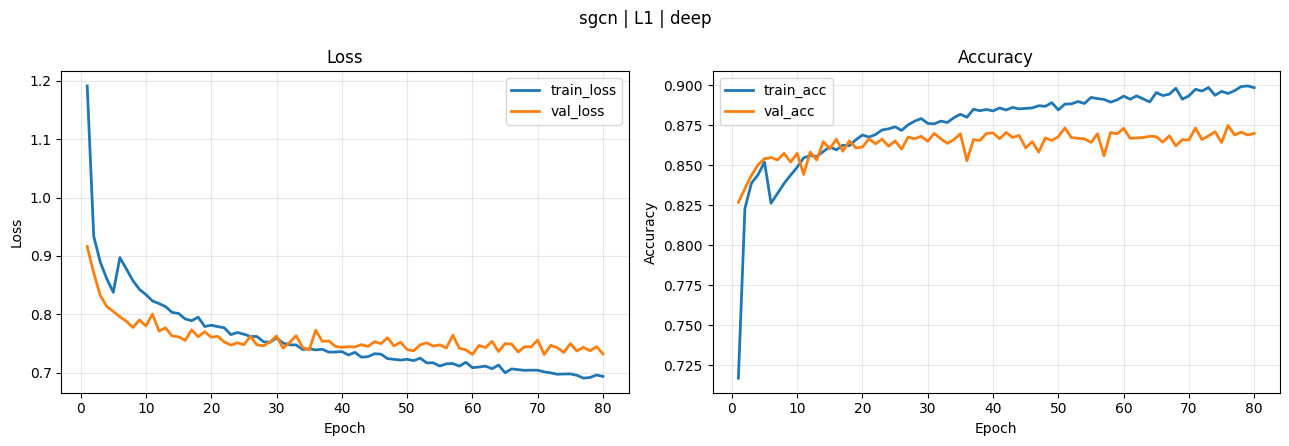

{'loss': 0.43416059163450466,
 'acc': 0.874437627811861,
 'macro_f1': 0.8235057306318765,
 'weighted_f1': 0.8754043839533873,
 'top1_acc': 0.874437627811861,
 'top3_acc': 0.9777096114519428,
 'top5_acc': 0.9946830265848671,
 'val_acc_best': 0.8748051948051948}

In [2]:
clear_cuda()
cfg_l1 = ExperimentConfig(
    method='sgcn', level='L1', feature_source='deep',
    epochs=80, batch_size=8, grad_accum_steps=4, lr=1e-3,
    hidden_dim=64, num_layers=2, dropout=0.5,
    use_logit_adjustment=False,
)
out_l1 = run_experiment(cfg_l1, ckpt_root=CKPT_ROOT, plot_root=PLOT_ROOT)
out_l1['metrics']

## L2 — manufacturer


=== SGCN | L2 | deep | hierarchical=False | tail_min=20 ===
Samples: train=15702 val=3850 test=4890 | classes=46
Tail-merge: kept 41/59 classes | coverage train=0.991 val=0.990 test=0.992
Gradient accumulation: micro_batch=8 effective_batch=32
AMP mixed precision: enabled
Epoch 001 | train_acc=0.2626 val_acc=0.4042 | train_loss=4.0552 val_loss=3.6600
Epoch 005 | train_acc=0.3909 val_acc=0.4416 | train_loss=3.4895 val_loss=3.3770
Epoch 010 | train_acc=0.4108 val_acc=0.4592 | train_loss=3.3955 val_loss=3.2919
Epoch 015 | train_acc=0.4188 val_acc=0.4532 | train_loss=3.3412 val_loss=3.2643
Epoch 020 | train_acc=0.4269 val_acc=0.4714 | train_loss=3.3085 val_loss=3.2364
Epoch 025 | train_acc=0.4313 val_acc=0.4751 | train_loss=3.2801 val_loss=3.2250
Epoch 030 | train_acc=0.4386 val_acc=0.4761 | train_loss=3.2506 val_loss=3.2004
Epoch 035 | train_acc=0.4445 val_acc=0.4925 | train_loss=3.2368 val_loss=3.1921
Epoch 040 | train_acc=0.4443 val_acc=0.4831 | train_loss=3.2246 val_loss=3.1889
Epoch 

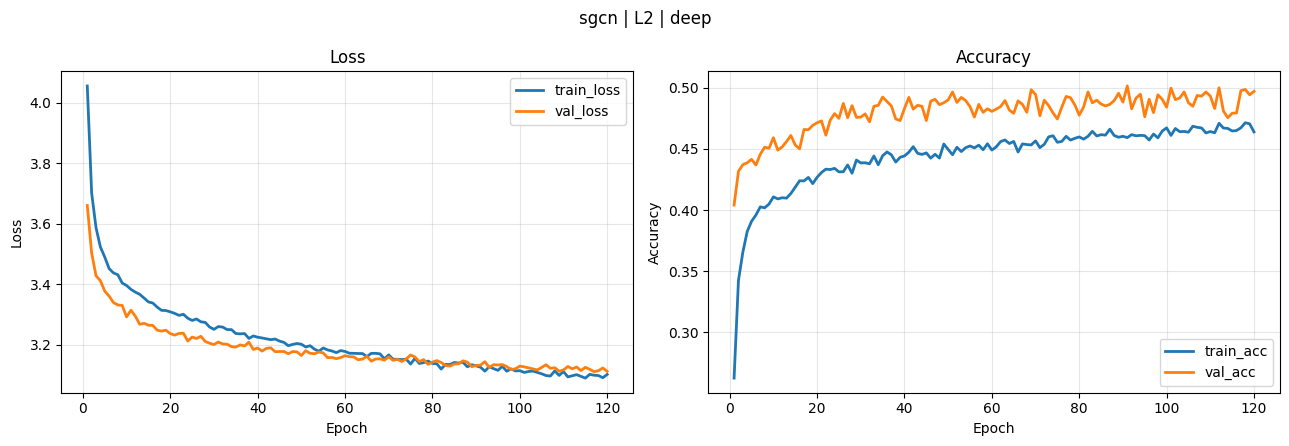

{'loss': 2.0939173158204873,
 'acc': 0.47730061349693254,
 'macro_f1': 0.2785864051430047,
 'weighted_f1': 0.44360280476633207,
 'top1_acc': 0.47730061349693254,
 'top3_acc': 0.7214723926380369,
 'top5_acc': 0.8194274028629857,
 'val_acc_best': 0.5015584415584415}

In [3]:
clear_cuda()
cfg_l2 = ExperimentConfig(
    method='sgcn', level='L2', feature_source='deep',
    epochs=120, batch_size=8, grad_accum_steps=4, lr=1e-3,
    hidden_dim=64, num_layers=2, dropout=0.5,
    hierarchical=False,
)
out_l2 = run_experiment(cfg_l2, ckpt_root=CKPT_ROOT, plot_root=PLOT_ROOT)
out_l2['metrics']

## L3 — model


=== SGCN | L3 | deep | hierarchical=False | tail_min=20 ===
Samples: train=15702 val=3850 test=4890 | classes=135
Tail-merge: kept 93/209 classes | coverage train=0.955 val=0.951 test=0.953
Gradient accumulation: micro_batch=8 effective_batch=32
AMP mixed precision: enabled
Epoch 001 | train_acc=0.0257 val_acc=0.1400 | train_loss=6.9548 val_loss=6.6272
Epoch 005 | train_acc=0.2105 val_acc=0.2756 | train_loss=6.2754 val_loss=6.1662
Epoch 010 | train_acc=0.2582 val_acc=0.3049 | train_loss=6.0953 val_loss=6.0339
Epoch 015 | train_acc=0.2777 val_acc=0.3379 | train_loss=6.0258 val_loss=5.9760
Epoch 020 | train_acc=0.2879 val_acc=0.3366 | train_loss=5.9621 val_loss=5.9309
Epoch 025 | train_acc=0.3014 val_acc=0.3455 | train_loss=5.9072 val_loss=5.9042
Epoch 030 | train_acc=0.3032 val_acc=0.3509 | train_loss=5.8823 val_loss=5.8743
Epoch 035 | train_acc=0.3094 val_acc=0.3725 | train_loss=5.8608 val_loss=5.8486
Epoch 040 | train_acc=0.3184 val_acc=0.3613 | train_loss=5.8416 val_loss=5.8547
Epoc

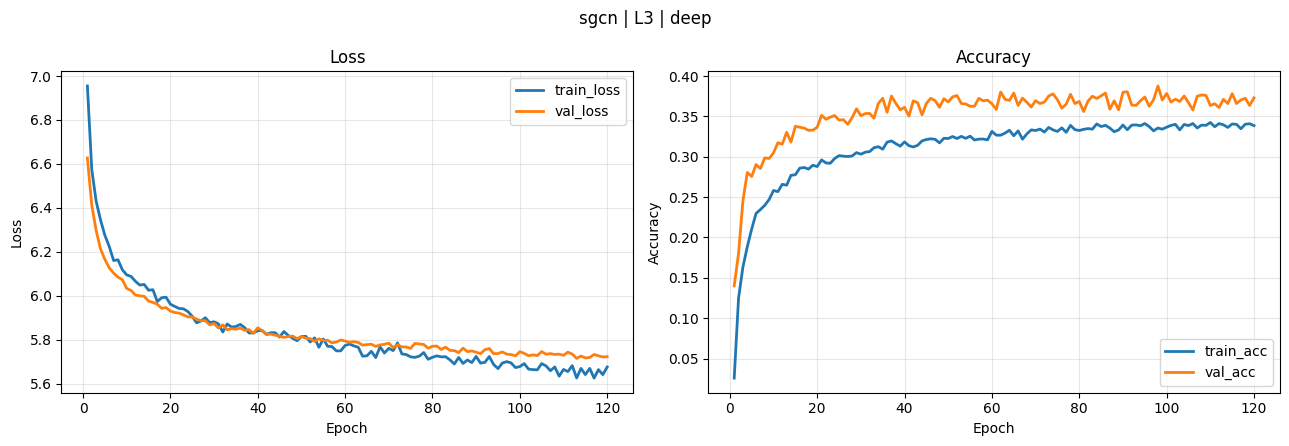

{'loss': 3.160263194140725,
 'acc': 0.35787321063394684,
 'macro_f1': 0.18200587915319477,
 'weighted_f1': 0.3584697735719165,
 'top1_acc': 0.35787321063394684,
 'top3_acc': 0.49734151329243353,
 'top5_acc': 0.5860940695296524,
 'val_acc_best': 0.3877922077922078}

In [4]:
clear_cuda()
cfg_l3 = ExperimentConfig(
    method='sgcn', level='L3', feature_source='deep',
    epochs=120, batch_size=8, grad_accum_steps=4, lr=1e-3,
    hidden_dim=64, num_layers=2, dropout=0.5,
    hierarchical=False,
)
out_l3 = run_experiment(cfg_l3, ckpt_root=CKPT_ROOT, plot_root=PLOT_ROOT)
out_l3['metrics']